qui provare a plottare la time series e vedere come cambia il sentiment se ci sono dei picchi

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATASET_PATH = r"C:\dev\nlp\datasets\meloni_with_sentiment.csv"


In [9]:
df = pd.read_csv(DATASET_PATH)

df.head()

print(df.count())

id                        12885
cid                       12885
created_at                12885
indexed_at                12885
text_raw                  12884
text_clean                12884
hashtags                  12885
keyword_source            12885
author_did                12885
author_handle             12885
author_display_name       10420
author_createdAt          12885
like_count                12885
repost_count              12885
reply_count               12885
quote_count               12885
bookmark_count            12885
viewer_like                   0
viewer_repost                 0
viewer_pinned                 0
viewer_bookmarked         12885
sent_ml_score             12885
sent_spec_score           12885
sentiment_multilingual    12885
sentiment_specific        12885
dtype: int64


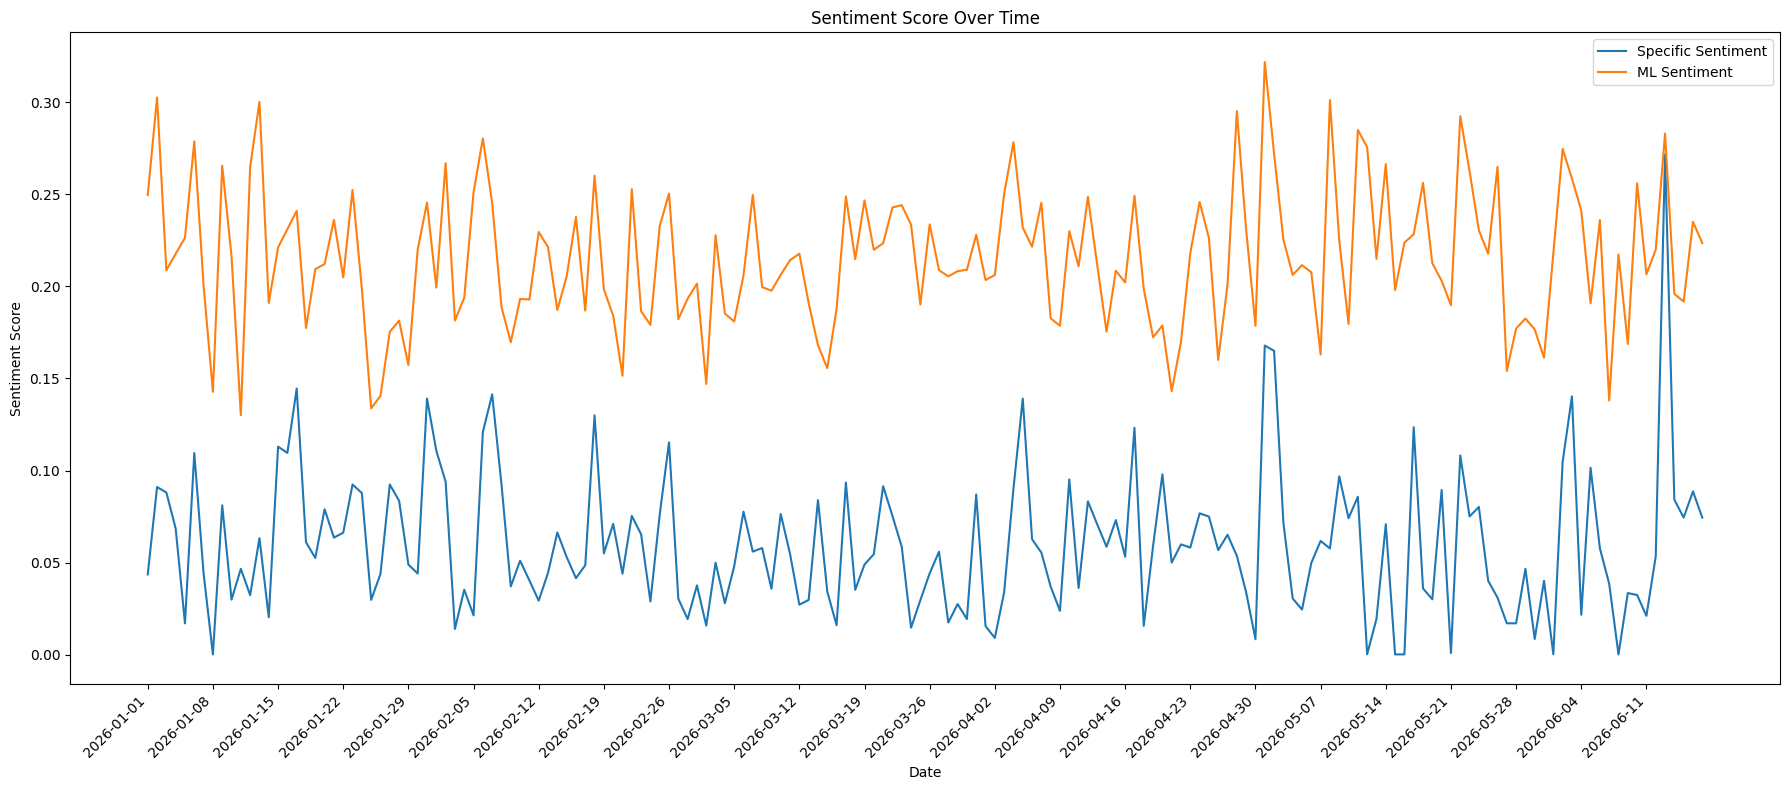

In [8]:
# normalizzo i createdAt in modo che conti solo il giorno e non anche l'ora
df["date_only"] = df["created_at"].str.split("T").str[0].replace("2026-", "")

# raggruppo per giorno e prendo la media del sentiment score
daily_sentiment_spec = df.groupby("date_only")["sent_spec_score"].mean().reset_index()
daily_sentiment_gen = df.groupby("date_only")["sent_ml_score"].mean().reset_index()

# plotto il sentiment nel tempo
plt.figure(figsize=(18, 8))

sns.lineplot(data=daily_sentiment_spec, x="date_only", y="sent_spec_score", label="Specific Sentiment")
sns.lineplot(data=daily_sentiment_gen, x="date_only", y="sent_ml_score", label="ML Sentiment")

plt.title("Sentiment Score Over Time")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.xticks(rotation=45, ha="right")

# show fewer date labels to make them readable
step = 7
ax = plt.gca()
ax.set_xticks(ax.get_xticks()[::step])

plt.tight_layout()
plt.show()

In [4]:
# conto i sentiments
print(df["sentiment_multilingual"].value_counts().reset_index())
print(df["sentiment_specific"].value_counts().reset_index())

  sentiment_multilingual  count
0               negative  10846
1               positive   1090
2                neutral    949
  sentiment_specific  count
0           negative  12118
1           positive    757
2            neutral     10


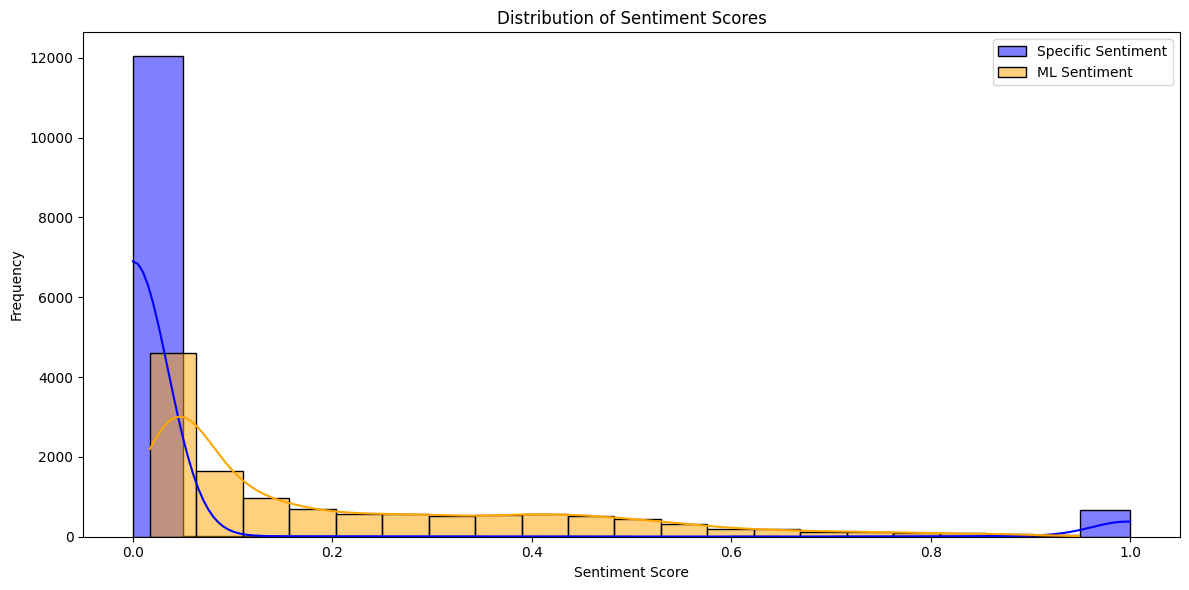

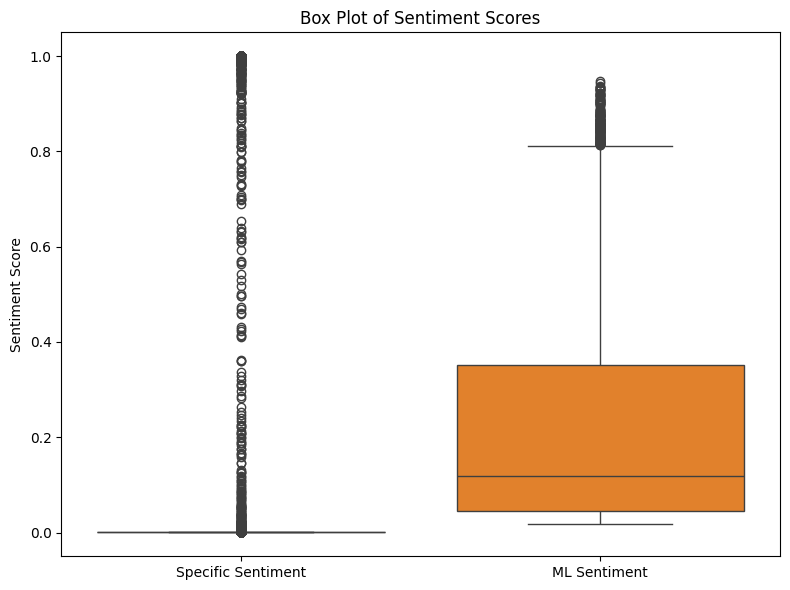

In [5]:
# plotto la distribuzione dei sentiment
plt.figure(figsize=(12, 6))
sns.histplot(df["sent_spec_score"], bins=20, kde=True, color="blue", label="Specific Sentiment")
sns.histplot(df["sent_ml_score"], bins=20, kde=True, color="orange", label="ML Sentiment")
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()

# box plot per confrontare i due sentiment
plt.figure(figsize=(8, 6))
sns.boxplot(data=df[["sent_spec_score", "sent_ml_score"]])
plt.title("Box Plot of Sentiment Scores")
plt.ylabel("Sentiment Score")
plt.xticks([0, 1], ["Specific Sentiment", "ML Sentiment"])
plt.tight_layout()
